# COSY by TPPI method - Make FIDs
## FIDs for COSY and P.COSY 2D spectra
### Author: John Price
-   For P.COSY see Marion and Bax, JMR 80 528-533 (1988)  
-   For TPPI method see Keeler p.231  
-   This method requires only one FID per t1 value and it moves T1 noise to edge of the spectrum.  
-   The P.COSY version has good line shapes.  

In [1]:
# Define the source path
SourcePath = '/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)

import pickle
import time
import numpy as np
import sympy as sp

%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
import PyOR_SignalProcessing as Spro
from PyOR_Plotting import Plotting
from PyOR_Evolution import Evolutions

### Set parameters

In [2]:
output_filename = 'COSY200Hz800Hz_0p5_1p0'   # without file extension

SW_1 = 400      # spectral width, t1 dimension (Hz)
                # equal to 1/dt1 where dt1 is the sampling period for t1
                # however, because of the real FT over t1 required by TPPI, the true
                # final spectral width is SW_1/2
SW_multiplier = 2          # spectral width multiplier, must be integer
SW_2 = SW_multiplier*SW_1  # spectral width for t2

t1_max = 0.5    # indirect dimension, longest t1 delay (s)
t2 = 1.0        # direct dimension, acquisition time (s)
T1 = 1.0        # T1 (s)
T2 = 0.5        # T2 (s)

offset_A = 40   # chemical shift offsets (Hz)
offset_B = -10
J_AB = 5.0      # J coupling (Hz)

# Initialize the spin system
Spin_list = {"A" : "H1", "B" : "H1"}
QS = QunS(Spin_list, PrintDefault=False)
QS.Initialize()

# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = offset_A
QS.OFFSET["B"] = offset_B

# J coupling between spins (Hz)
QS.JcoupleValue("A","B",J_AB)

# B0 in TeslaZ
QS.B0 = 125.0/42.58

# Master equation
QS.PropagationSpace = "Hilbert"
QS.MasterEquation = "Redfield"
QS.OdeMethod = 'DOP853'
QS.PropagationMethod = "ODE Solver"            

# Define initial and final Spin Temperature
QS.I_spintemp["A"] = 300.0
QS.I_spintemp["B"] = 300.0
QS.F_spintemp["A"] = 300.0
QS.F_spintemp["B"] = 300.0

# Relaxation Process
QS.Rprocess = "Phenomenological"
QS.R1 = 1/T1
QS.R2 = 1/T2

QS.Update()

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


### Generate Hamiltonians

In [3]:
# generate Larmor Frequencies
QS.print_Larmor = True
Ham = Hamiltonian(QS)
Hz = Ham.Zeeman_RotFrame()
Hj = Ham.Jcoupling()

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


## Product operator basis

In [4]:
BS = Basis(QS)
Index = False
Normal = True
Basis_Cart, dic_Cart = BS.ProductOperators_SpinHalf_Cartesian(Index,Normal)

## Initialize density matrix

In [5]:
DM = DensityMatrix(QS,Ham)

rho_initial = QS.Az + QS.Bz        # both spins polarized
rhoeq = QS.Az + QS.Bz
# rho_initial = QS.Az               # don't polarize B spin (for tests only)
# rhoeq = QS.Az

DM.DensityMatrix_Components(rho_initial,Basis_Cart,dic_Cart)

Density Matrix = 1.0 Id1 Iz2  + 1.0 Iz1 Id2 


## Excitation pulse

In [6]:
HardP = HardPulse(QS)
rho_0 = HardP.Rotate_Pulse(rho_initial, 90, QS.Ay+QS.By)  # phase of 0 --> x-axis
DM.DensityMatrix_Components(rho_0,Basis_Cart,dic_Cart)

Density Matrix = 1.0 Id1 Ix2  + 1.0 Ix1 Id2 


## Evolution

In [7]:
# observables
det_Mt = QS.Ap + QS.Bp    # acquire complex FID
det_Mz = QS.Az + QS.Bz    # also track Mz

EVol = Evolutions(QS,Ham)
start_time = time.time()

# generate template rho and FID, use this for initial state before 2nd pulse
# will also use for P.COSY purge subtraction so need FID to the end of t2 for longest t1
dt2 = 1/SW_2           # sampling period in seconds
EVol.AcqFS = SW_2
EVol.AcqDT = dt2  
EVol.AcqAQ = t1_max + t2

t_template, rho_template = EVol.Evolution(rho_0,rhoeq,Hz+Hj)

_, FID_template = EVol.Expectation(rho_template,det_Mt)
_, Mz_template = EVol.Expectation(rho_template,det_Mz)

FID_template_90 = Spro.PhaseAdjust_FID(FID_template,90) # phase shifted template FID is needed for PCOSY

FID_template_phased = [FID_template, FID_template_90, -FID_template, -FID_template_90]

Larmor Frequency in MHz:  [-124.99255023 -124.99250023]


In [8]:
# generate FID arrays after both pulses
EVol.AcqAQ = t2
Npoints_t2 = EVol.Compute_Npoints(EVol.AcqAQ,dt2) 
dt1 = 1/SW_1
Npoints_t1 = EVol.Compute_Npoints(t1_max,dt1) 

t1_array = EVol.Compute_Tpoints(Npoints_t1,dt1)# np.linspace(0,dt1*(Npoints_t1-1),Npoints_t1,endpoint=True)
t2_array = EVol.Compute_Tpoints(Npoints_t2,dt2)# np.linspace(0,dt2*(Npoints_t2-1),Npoints_t2,endpoint=True)

FID_array = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)
PFID_array = np.zeros([Npoints_t1,Npoints_t2], dtype=complex)

print('generating FIDs: ', end='')

for i in range(Npoints_t1):
    if (i+1)%10 == 0: print(f'.{i+1}',end='')                 # report progress
    phi = 90*(i%4)                                            # 0,90,180,270,0,90,...
    rho_initial = QunObj(rho_template[i*SW_multiplier])                      # just before 2nd pulse, phase of 1st pulse was 0
    rho_initial_phi = HardP.Rotate_Pulse(rho_initial,phi,QS.Az+QS.Bz)        # just before 2nd pulse, phase of 1st pulse was phi
    rho_initial_phi_0 = HardP.Rotate_Pulse(rho_initial_phi,90,QS.Ay+QS.By)   # after 2nd pulse, pulse phases were (phi,0)

    _, rho_TPPI = EVol.Evolution(rho_initial_phi_0,rhoeq,Hz+Hj)              # evolve density matrix after second pulse
 
    _, FID_array[i] = EVol.Expectation(rho_TPPI,det_Mt)                      # generate the FID array

    PFID_array[i,:] = FID_array[i,:] - FID_template_phased[i%4][i*SW_multiplier:i*SW_multiplier+Npoints_t2]    # subtract phase rotated template FID for PCOSY
    
print()
print(f'template FID shape: {FID_template.shape}, template time series length: {len(t_template)}')
print(f'FID array shape: {FID_array.shape}')
print(f'PFID array shape: {PFID_array.shape}')

end_time = time.time()
time_taken = end_time - start_time
print("Total time = %s seconds " % (time_taken))

generating FIDs: .10.20.30.40.50.60.70.80.90.100.110.120.130.140.150.160.170.180.190.200
template FID shape: (1201,), template time series length: 1201
FID array shape: (201, 801)
PFID array shape: (201, 801)
Total time = 103.27398562431335 seconds 


## Save FID arrays 

In [9]:
COSY_FIDs = {}
COSY_FIDs['time_taken'] = time_taken
COSY_FIDs['offset_A'] = offset_A
COSY_FIDs['offset_B'] = offset_B
COSY_FIDs['J_AB'] = J_AB
COSY_FIDs['FID_template_phased'] = FID_template_phased
COSY_FIDs['Mz_template'] = Mz_template
COSY_FIDs['t_template'] = t_template
COSY_FIDs['FID_array'] = FID_array
COSY_FIDs['PFID_array'] = PFID_array
COSY_FIDs['t1_array'] = t1_array
COSY_FIDs['t2_array'] = t2_array

file = open(output_filename + '.pickle', 'ab')
pickle.dump(COSY_FIDs, file)                    
file.close()

## Plotting

In [10]:
plot = Plotting(QS)

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7f62bfa66900>)

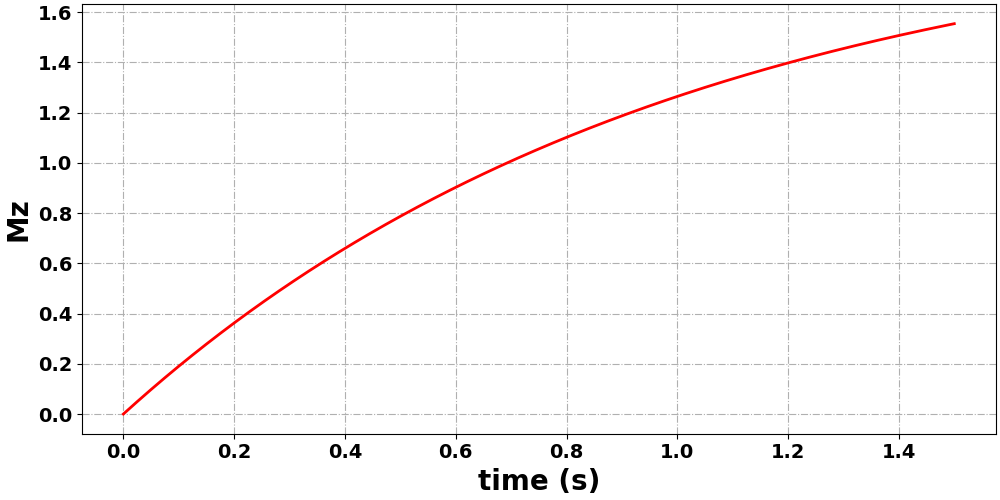

In [11]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting_SpanSelector(t_template,Mz_template.real,"time (s)","Mz","red") 

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7f62bf922e10>)

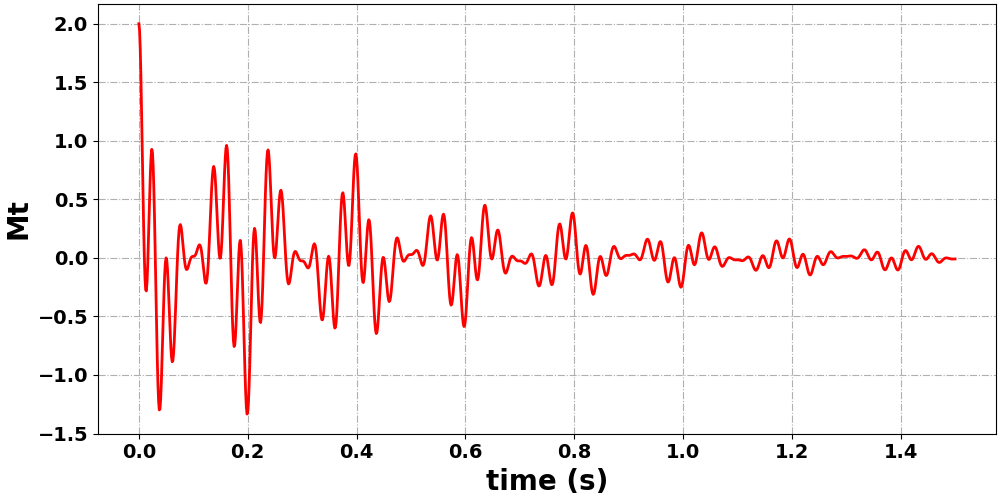

In [12]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting_SpanSelector(t_template,FID_template_phased[0].real,"time (s)","Mt","red") 

In [13]:
zero_fill = 10 
SW_template = 1/(t_template[1]-t_template[0])
freq, spectrum = Spro.FourierTransform(FID_template_phased[0],SW_template,zero_fill)

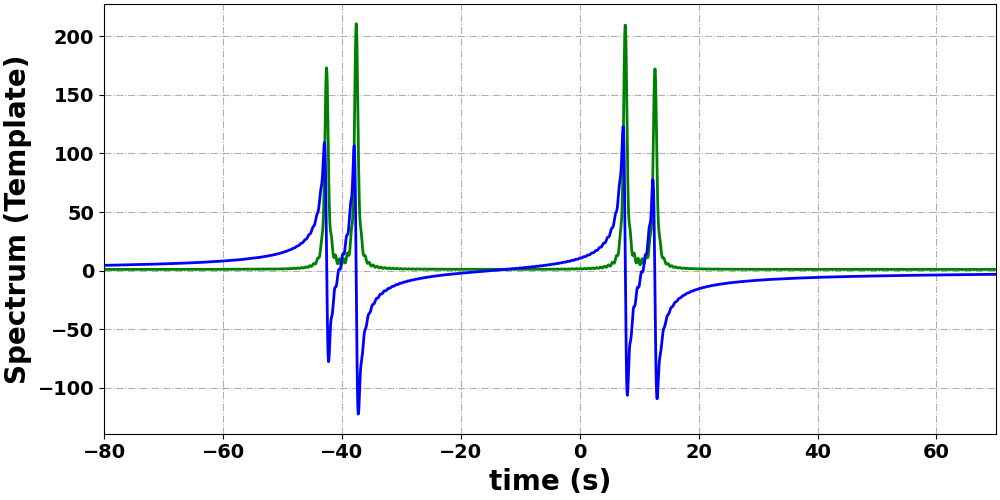

In [14]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.PlotXlimt = (-80,70)
plot.PlottingMulti([freq,freq],[spectrum.real,spectrum.imag],"time (s)","Spectrum (Template)",["green","blue"])

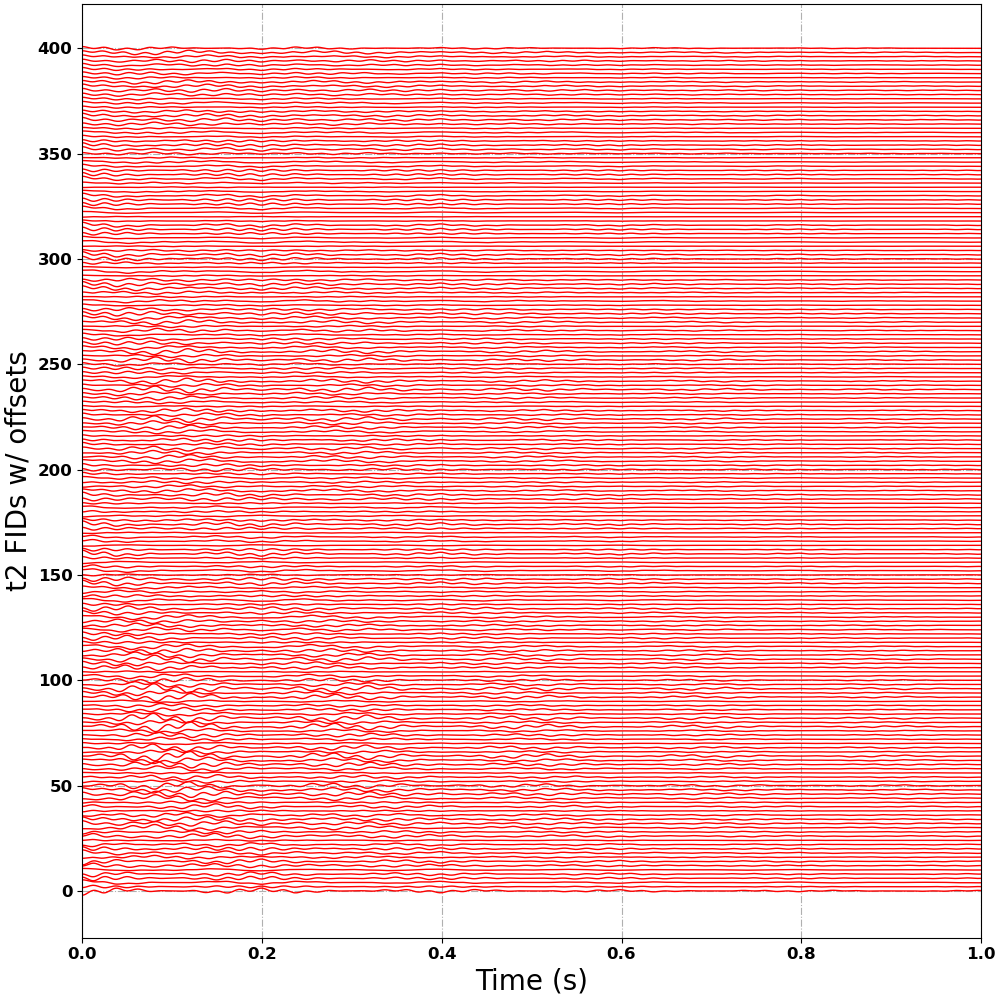

In [15]:
plot.PlotFigureSize = (10,10)
plot.PlotXlimt = (0,1)
plot.PlotLinwidth = 1.0
plot.Plotting2DArray(t2_array, PFID_array,"Time (s)", "t2 FIDs w/ offsets", color="red", offset=2.0)

In [16]:
freqs_t2, Spectrum_over_t2 = Spro.FourierTransform2D_DirectDimension_COSY_TPPI(
    FID_array  = PFID_array,
    t1_array   = t1_array,
    t2_array   = t2_array,
    zero_fill  = 10,
    df_t1      = 0.5,
    df_t2      = 0.5,
    phase1_deg = 0.0
)


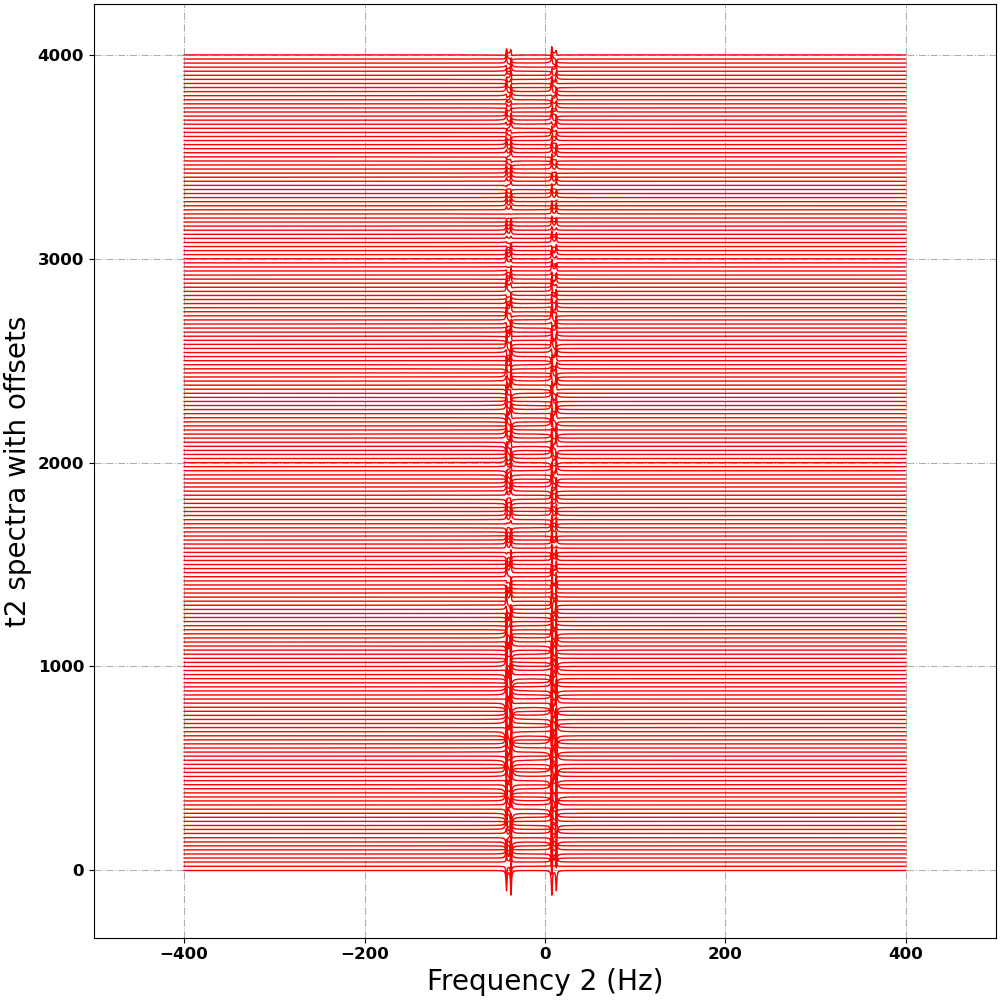

In [17]:
plot.PlotFigureSize = (10,10)
plot.PlotXlimt = (-500,500)
plot.PlotLinwidth = 1.0
plot.Plotting2DArray(freqs_t2, Spectrum_over_t2,"Frequency 2 (Hz)","t2 spectra with offsets", color="red", offset=20.0)

In [18]:
freqs_t1, Spectrum_2D = Spro.FourierTransform2D_IndirectDimension_COSY_TPPI(
    Spectrum_over_t2 = Spectrum_over_t2,
    t1_array         = t1_array,
    zero_fill        = 10,
    phase2_deg       = 180
)

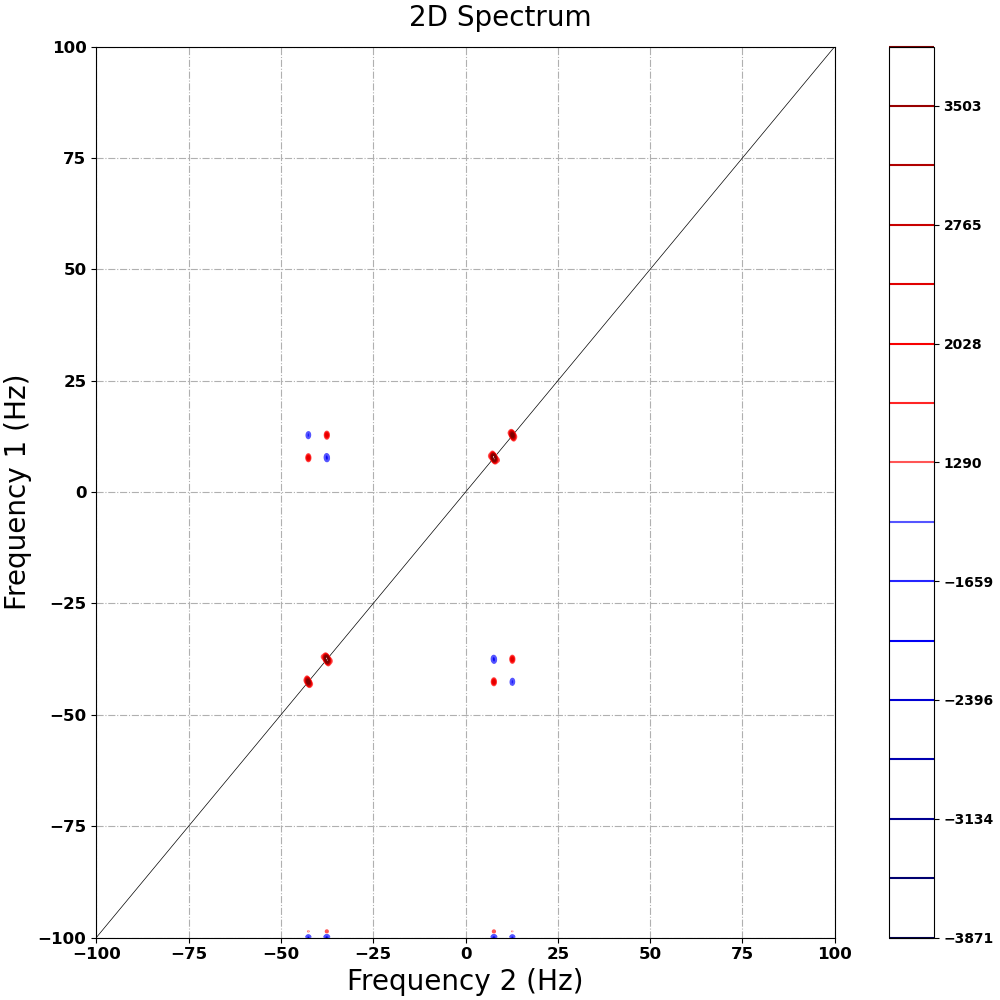

In [19]:
plot.PlotFigureSize = (10,10)
plot.PlotXlimt = (-100,100)
plot.PlotYlimt = (-100,100)
plot.PlottingContour_COSY(
    x=freqs_t2,
    y=freqs_t1,
    z=Spectrum_2D.real,
    xlab="Frequency 2 (Hz)",
    ylab="Frequency 1 (Hz)",
    title="2D Spectrum",
    nlevels=8,
    lift=2.5,
    scale=0.5
)